# Decision Tree Classifier on Vehicle Coupon Recommendation Dataset

This notebook implements a Decision Tree classifier to predict whether a driver will accept a coupon. We will perform data preprocessing, including scaling and encoding, followed by model training, hyperparameter tuning via RandomizedSearchCV, and evaluation with classification metrics and visualizations.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, roc_curve
import pickle
import json
import os

## 1. Data Loading

In [11]:
# Load the dataset
try:
    df = pd.read_csv('../in-vehicle-coupon-recommendation.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset not found! Please check the path.")

# Display info to identify columns
df.info()

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar    

In [12]:
# Display first few rows
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [13]:
# Drop duplicates
df = df.drop_duplicates()

# Drop 'car' column if >90% null
if 'car' in df.columns and df['car'].isnull().mean() > 0.9:
    print("Dropping 'car' column due to >90% missing values.")
    df = df.drop(columns=['car'])

# --- Ordinal Encoding for ordered categorical columns ---
FREQUENCY_ORDER = ['never', 'less1', '1~3', '4~8', 'gt8']
AGE_ORDER = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
INCOME_ORDER = [
    'Less than $12500', '$12500 - $24999', '$25000 - $37499',
    '$37500 - $49999', '$50000 - $62499', '$62500 - $74999',
    '$75000 - $87499', '$87500 - $99999', '$100000 or More'
]
EXPIRATION_ORDER = ['2h', '1d']
TIME_MAP = {'7AM': 7, '10AM': 10, '2PM': 14, '6PM': 18, '10PM': 22}
FREQUENCY_COLS = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

# Map frequency columns to numeric
freq_map = {v: i for i, v in enumerate(FREQUENCY_ORDER)}
for col in FREQUENCY_COLS:
    if col in df.columns:
        df[col] = df[col].map(freq_map)

# Map age to numeric
age_map = {v: i for i, v in enumerate(AGE_ORDER)}
if 'age' in df.columns:
    df['age'] = df['age'].map(age_map)

# Map income to numeric
income_map = {v: i for i, v in enumerate(INCOME_ORDER)}
if 'income' in df.columns:
    df['income'] = df['income'].map(income_map)

# Map expiration to numeric
exp_map = {v: i for i, v in enumerate(EXPIRATION_ORDER)}
if 'expiration' in df.columns:
    df['expiration'] = df['expiration'].map(exp_map)

# Map time to numeric hour
if 'time' in df.columns:
    df['time'] = df['time'].map(TIME_MAP)

# --- Feature Engineering ---
freq_available = [c for c in FREQUENCY_COLS if c in df.columns]
if freq_available:
    df['total_visits'] = df[freq_available].sum(axis=1)
    print(f"Added 'total_visits' feature (sum of {freq_available})")

if 'passanger' in df.columns:
    df['is_alone'] = (df['passanger'] == 'Alone').astype(int)
    print("Added 'is_alone' feature")

# Separate Target and Features
X = df.drop(columns=['Y'])
y = df['Y']

# Identify Numerical and Categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")

Dropping 'car' column due to >90% missing values.
Added 'total_visits' feature (sum of ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50'])
Added 'is_alone' feature
Numerical Features (18): ['temperature', 'time', 'expiration', 'age', 'has_children', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'total_visits', 'is_alone']
Categorical Features (8): ['destination', 'passanger', 'weather', 'coupon', 'gender', 'maritalStatus', 'education', 'occupation']


## 2. Data Preprocessing

In [14]:
# Define Preprocessing Pipeline
# Decision Trees don't strictly need scaling, but we include it
# for consistency with the other model pipelines in this project.

# Numerical Transformer: Impute median (if any missing) -> Scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Transformer: Impute 'missing' -> OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

## 3. Train-Test Split

In [15]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create Model Pipeline with class_weight='balanced'
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt)
])

# Hyperparameter grid for RandomizedSearchCV
param_distributions = {
    'classifier__max_depth': [5, 10, 15, 20, 25, 30, 40, None],
    'classifier__min_samples_split': [2, 3, 5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 3, 4, 5],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_features': ['sqrt', 'log2', None],
}

# RandomizedSearchCV: 30 iterations, 5-fold CV, f1_weighted scoring
search = RandomizedSearchCV(
    clf,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best Parameters: {search.best_params_}")
print(f"Best CV Score (f1_weighted): {search.best_score_:.4f}")

# Use best estimator for predictions
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Model Trained Successfully!")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'classifier__min_samples_split': 15, 'classifier__min_samples_leaf': 3, 'classifier__max_features': None, 'classifier__max_depth': 30, 'classifier__criterion': 'gini'}
Best CV Score (f1_weighted): 0.6795
Model Trained Successfully!


## 4. Evaluation

Test Set Accuracy: 0.6586


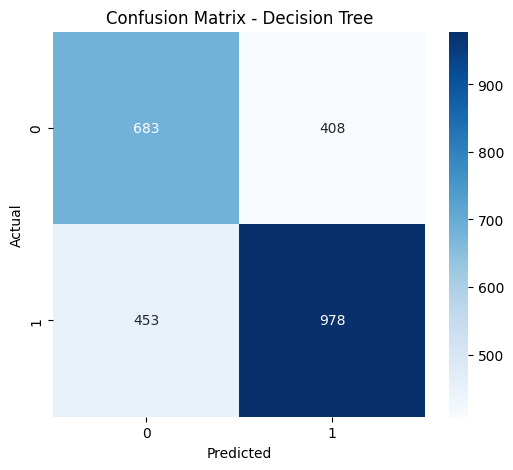

In [16]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 5. Visualization: Max Depth vs Accuracy

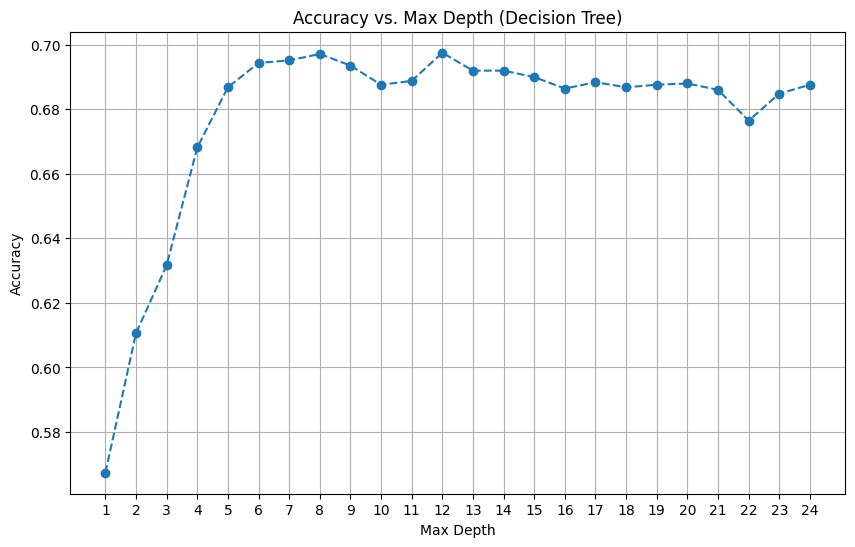

In [17]:
# Visualize how test accuracy changes with max_depth
depth_values = range(1, 25)
acc_scores = []

for d in depth_values:
    temp_clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    temp_clf.fit(X_train, y_train)
    acc = temp_clf.score(X_test, y_test)
    acc_scores.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(list(depth_values), acc_scores, marker='o', linestyle='dashed')
plt.title('Accuracy vs. Max Depth (Decision Tree)')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(list(depth_values))
plt.grid(True)
plt.show()

## 6. Feature Importance

/var/folders/1g/qb6xwhq93b57bjwbpxmxdngm0000gn/T/ipykernel_99951/139052500.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


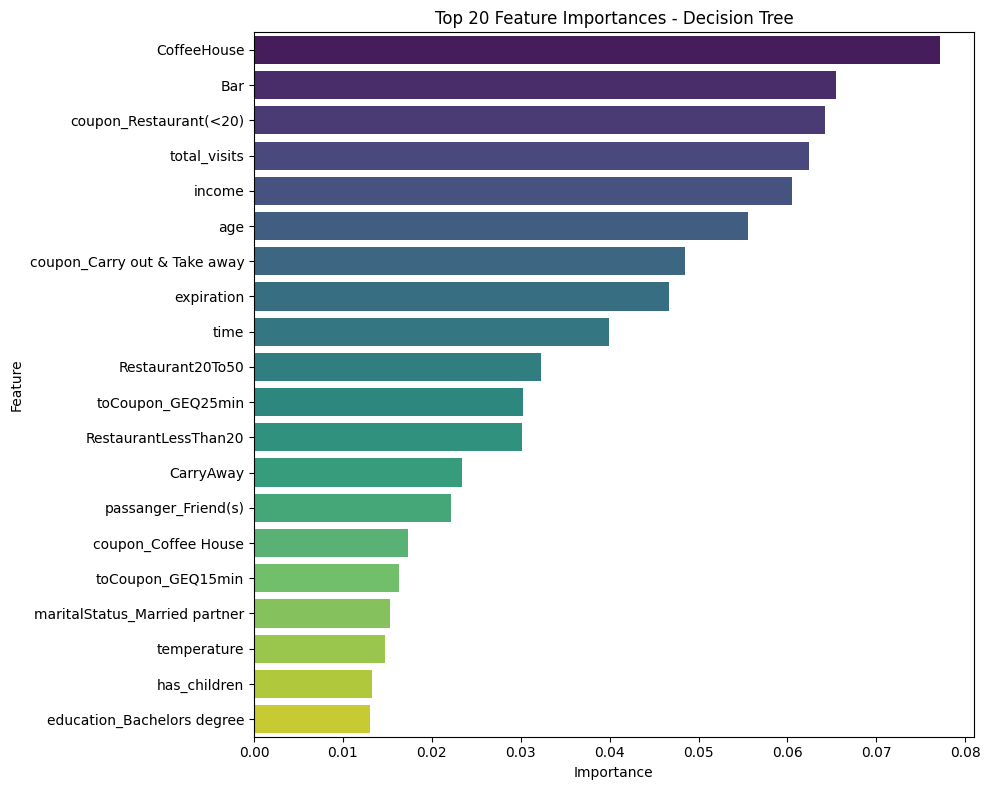

In [18]:
# Get the trained Decision Tree classifier from the best pipeline
dt_model = best_model.named_steps['classifier']
preprocessor_fitted = best_model.named_steps['preprocessor']

# Get feature names from the preprocessor
num_features = numerical_cols
cat_features = preprocessor_fitted.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols).tolist()
all_features = num_features + cat_features

# Feature importances
importances = dt_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(20)
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 20 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()